In [1]:
# pip install certain packages
!pip install langchain_openai


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# packages
import os
import numpy as np
import pandas as pd 
from dotenv import load_dotenv
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from langchain_openai import OpenAI, OpenAIEmbeddings

In [3]:
# loading embedding data
embedding_file_path = "embedding_data/ExioNAICS_embeddings.csv"
embeddings_created = True

try: 
    embeds = pd.read_csv(embedding_file_path)
    embeds.drop(embeds.columns[0], axis=1, inplace=True)
    print("Embeddings exist!")
except:
    embeddings_created = False
    print("Embeddings do not exist.")

Embeddings exist!


In [4]:
# loading data
df = pd.read_csv('../ExioNAICS.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

Shape: (20535, 29)

Columns:
['Company Name', 'Company Description', 'NAICS Code', 'NAICS Title', '2022 NAICS Code', '2022 NAICS Title', '2017 NAICS Code', '2017 NAICS Title', 'Description', 'NAICS_5 Code', 'NAICS_5 Title', 'NAICS_5 Description', 'NAICS_4 Code', 'NAICS_4 Title', 'NAICS_4 Description', 'NAICS_3 Code', 'NAICS_3 Title', 'NAICS_3 Description', 'NAICS_2 Code', 'NAICS_2 Title', 'NAICS_2 Description', 'ExioML', 'region', 'Value Added [M.EUR]', 'Employment [1000 p.]', 'GHG emissions [kg CO2 eq.]', 'Energy Carrier Net Total [TJ]', 'Year', 'Carbon Intensity']


,Company Name,Company Description,NAICS Code,NAICS Title,2022 NAICS Code,2022 NAICS Title,2017 NAICS Code,2017 NAICS Title,Description,NAICS_5 Code,...,NAICS_2 Title,NAICS_2 Description,ExioML,region,Value Added [M.EUR],Employment [1000 p.],GHG emissions [kg CO2 eq.],Energy Carrier Net Total [TJ],Year,Carbon Intensity
0,Foot Locker Specialty Inc,Foot Locker Inc (Foot Locker) is a specialty r...,448150,Clothing Accessories Stores,458110,Clothing and Clothing Accessories Retailers,448150,Clothing Accessories Stores,This industry comprises establishments primari...,45811,...,Retail Trade,The Sector as a Whole\n\nThe Retail Trade sect...,"Retail trade services, except of motor vehicl...",US,155839.081079,26252.194517,1.974719e+08,3603.462783,2022,0.001267
1,Cengage Learning Inc,Cengage is the education and technology compan...,511130,Book Publishers,513130,Book Publishers,511130,Book Publishers,This industry comprises establishments known a...,51313,...,Information,The Sector as a Whole\n\nThe Information secto...,Printed matter and recorded media (22),US,101252.173354,359.127253,8.762522e+09,269198.419669,2022,0.086542
2,Cardinal Scale Mfg Co,Cardinal Scale Manufacturing Company manufactu...,333997,Scale and Balance Manufacturing,333998,All Other Miscellaneous General Purpose Machin...,333997,Scale and Balance Manufacturing,This U.S. industry comprises establishments pr...,33399,...,Manufacturing,The Sector as a Whole\n\nThe Manufacturing sec...,"Medical, precision and optical instruments, wa...",US,163416.090875,242.560449,6.744317e+09,172060.328352,2022,0.041271
3,Alticor Inc,Alticor Inc. owns and manages manufacturing an...,454390,Other Direct Selling Establishments,441330,Automotive Parts and Accessories Retailers,454390,Other Direct Selling Establishments,This industry comprises establishments primari...,44133,...,Retail Trade,The Sector as a Whole\n\nThe Retail Trade sect...,"Retail trade services, except of motor vehicl...",US,155839.081079,26252.194517,1.974719e+08,3603.462783,2022,0.001267
4,S Butler-Rosboro Corporation,Rosboro is North America's largest producer of...,335110,Electric Lamp Bulb and Part Manufacturing,335139,Electric Lamp Bulb and Other Lighting Equipmen...,335110,Electric Lamp Bulb and Part Manufacturing,This U.S. industry comprises establishments pr...,33513,...,Manufacturing,The Sector as a Whole\n\nThe Manufacturing sec...,Electrical machinery and apparatus n.e.c. (31),US,68675.538658,809.436143,3.051654e+09,101481.364669,2022,0.044436


In [5]:
# consistent train test split
X_train_val, X_test = train_test_split(
    df, 
    test_size = 0.1, 
    stratify = df['NAICS_2 Code'], 
    random_state = 192
)

X_train, X_val = train_test_split(
    X_train_val, 
    test_size = 0.125, 
    stratify = X_train_val['NAICS_2 Code'], 
    random_state = 192
)

print('=' * 22 + "( Split Sizes )" + '=' * 22)
print('Train Size: ' + str(len(X_train)) + " | " + 'Validation Size: ' + str(len(X_val)) + ' | ' + 'Test Size: ' + str(len(X_test)))

======================( Split Sizes )======================
Train Size: 16170 | Validation Size: 2311 | Test Size: 2054


In [6]:
input = df[['Company Name', 'Company Description' , 'NAICS_2 Code', 'NAICS Code']] 
input.head()

,Company Name,Company Description,NAICS_2 Code,NAICS Code
0,Foot Locker Specialty Inc,Foot Locker Inc (Foot Locker) is a specialty r...,45,448150
1,Cengage Learning Inc,Cengage is the education and technology compan...,51,511130
2,Cardinal Scale Mfg Co,Cardinal Scale Manufacturing Company manufactu...,33,333997
3,Alticor Inc,Alticor Inc. owns and manages manufacturing an...,44,454390
4,S Butler-Rosboro Corporation,Rosboro is North America's largest producer of...,33,335110


In [7]:
# given how similar the classes are below, we merged them to improve accuracy (because at the NAICS-2 level there isn't a difference between them)
SECTOR_MERGE = {
    '31': '31-33', '32': '31-33', '33': '31-33',
    '44': '44-45', '45': '44-45',
    '48': '48-49', '49': '48-49',
} 

df['NAICS_2 Code'] = df['NAICS_2 Code'].apply(lambda x : SECTOR_MERGE.get(str(x), str(x)))
df['NAICS_2 Code'].head()

0    44-45
1       51
2    31-33
3    44-45
4    31-33
Name: NAICS_2 Code, dtype: object

## Custom NLP Extractions

In [8]:
descriptions = list(input['Company Description']) 

descriptions_cleaned = [desc.replace("\n", "") for desc in descriptions]
input['Company Description'] = descriptions_cleaned

/var/folders/g_/3919h1zn6j5929j3xzypx62w0000gn/T/ipykernel_8201/220697868.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input['Company Description'] = descriptions_cleaned


### Make sure to configure the path properly so you don't have to unnecessarily create new embedding (very costly)

In [9]:
if not embeddings_created:
    # set up environmental key
    load_dotenv()
    OpenAI_key = os.getenv('OPENAI_API_KEY')

    # set up an embedder and embed the descriptions
    embedder = OpenAIEmbeddings()

    text_list = set(list(input['Company Description']))

    # turn all unique descriptions into embeddings
    embeddings = []
    progress_bar = 0
    for item in text_list:
        embeddings.append(embedder.embed_query(item))
        progress_bar += 1
        
        if progress_bar % 130 == 0:
            print(f'Embeddings are {round(progress_bar / len(text_list), 6) * 100}% Complete.')

    print("Embeddings are 100% Complete")

    # create a dictionary to map values
    embeddings_map = {}
    desc = list(text_list)

    for i in range(len(desc)):
        embeddings_map[desc[i]] = embeddings[i]
        
    # assing embeddings to values
    final_embeddings = [embeddings_map[x] for x in input['Company Description']]
    input['embeddings'] = final_embeddings

    # export embeddings
    input.to_csv("ExioNAICS_embeddings.csv")

else:
    print(embeds.head())

                   Company Name  \
0     Foot Locker Specialty Inc   
1          Cengage Learning Inc   
2         Cardinal Scale Mfg Co   
3                   Alticor Inc   
4  S Butler-Rosboro Corporation   

                                 Company Description  NAICS_2 Code  \
0  Foot Locker Inc (Foot Locker) is a specialty r...            45   
1  Cengage is the education and technology compan...            51   
2  Cardinal Scale Manufacturing Company manufactu...            33   
3  Alticor Inc. owns and manages manufacturing an...            44   
4  Rosboro is North America's largest producer of...            33   

   NAICS Code                                         embeddings  
0      448150  [-0.005645981058478355, -0.008253282867372036,...  
1      511130  [-0.008275656960904598, 0.0007852395647205412,...  
2      333997  [0.009580505080521107, 0.006520636845380068, 0...  
3      454390  [0.006441702600568533, -0.027760904282331467, ...  
4      335110  [-0.01356643438339

In [10]:
# turn embeddings into proper numbers instead of string
embeds['embeddings'] = embeds['embeddings'].apply(lambda x: x[1:-1])
new_embeds = embeds['embeddings'].apply(lambda x: pd.Series(x.split(", ")))
new_embeds = new_embeds.map(lambda x: float(x))
new_embeds.head()

,0,1,2,3,4,5,6,7,8,9,...,1526,1527,1528,1529,1530,1531,1532,1533,1534,1535
0,-0.005646,-0.008253,-0.008444,-0.020770,-0.011006,-0.001654,-0.030958,-0.021379,0.027456,-0.012009,...,0.017864,-0.018194,0.034789,0.001604,0.001005,-0.004035,-0.001431,-0.009630,0.017052,-0.012053
1,-0.008276,0.000785,0.013819,-0.025624,-0.016368,0.024762,-0.004742,-0.019990,-0.015518,-0.027455,...,0.008125,0.025690,0.012348,-0.015505,-0.041339,-0.022448,0.003425,-0.035168,0.012342,-0.003510
2,0.009581,0.006521,0.009286,-0.018983,-0.017585,0.014871,-0.006671,-0.008429,-0.016941,-0.012534,...,0.004119,-0.018133,0.018078,-0.011239,0.004818,-0.011671,-0.003082,-0.000388,-0.026151,-0.020641
3,0.006442,-0.027761,-0.003328,-0.036988,-0.008563,0.041446,-0.024450,0.019354,0.004663,0.002535,...,0.033209,-0.004907,0.038135,0.002194,0.009319,0.001169,-0.009312,0.005712,-0.009358,-0.007605
4,-0.013566,-0.018146,-0.022128,-0.019832,0.005605,-0.011024,-0.014907,0.030823,-0.017376,-0.005121,...,0.015704,-0.009969,0.015504,-0.003043,-0.013394,-0.011290,0.005522,-0.007633,-0.012730,-0.017389


In [11]:
# verify everything's a number now
new_embeds.dtypes.value_counts()

float64    1536
Name: count, dtype: int64

### Perform PCA to simplify embeddings and speed up training time!

In [12]:
# first we do PCA to preserve the embeddings but also speed up training
# make a copy of the data first
simple_embed = new_embeds.copy(deep=True)

# initialize
pca = PCA()

# fit transform
pca.fit(simple_embed)

simple_embed = pca.transform(simple_embed)

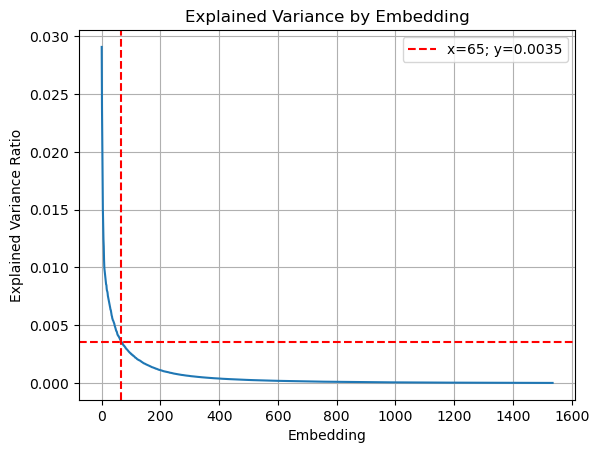

In [13]:
import matplotlib.pyplot as plt

# seems like to preserve the most amount of components we only need to store 65 embeddings
plt.plot(pca.explained_variance_ratio_)
plt.title("Explained Variance by Embedding")
plt.axvline(x=65, color='red', linestyle='dashed', label='x=65; y=0.0035')
plt.axhline(y=0.0035, color='red', linestyle='dashed')
plt.xlabel("Embedding")
plt.ylabel("Explained Variance Ratio")
plt.grid()
plt.legend()
plt.show()

# using Elbow method it seems that the top 65 embeddings are best

In [14]:
# keep the first 65 components
re_embed = pd.DataFrame(data=simple_embed)
re_embed = re_embed[np.arange(0, 65)]
re_embed

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,-0.041112,-0.112960,-0.080920,-0.099232,0.082329,-0.015508,-0.027714,0.006002,-0.033898,0.044550,...,0.047427,-0.016113,-0.010229,0.022226,-0.015795,0.017871,-0.007276,0.111862,-0.019273,0.021792
1,-0.094145,0.093264,0.048834,-0.123809,-0.012231,0.039828,0.023074,-0.077292,-0.016948,-0.042535,...,0.026619,-0.054289,-0.015423,0.051578,0.034017,0.022119,0.024983,0.047409,0.040793,-0.016668
2,0.135538,-0.015154,0.004572,0.021409,0.018874,-0.066014,-0.052755,0.053448,-0.017834,-0.095663,...,-0.010196,-0.016800,-0.008203,-0.007710,0.002686,0.075651,0.030180,-0.014289,-0.029554,0.019630
3,0.024154,0.012677,-0.130014,0.003572,-0.006198,0.000022,-0.013069,0.017968,0.040630,0.042239,...,0.018562,0.027187,-0.040850,0.038527,-0.038558,-0.023927,0.010753,0.037503,-0.045228,0.047263
4,0.106364,-0.061147,0.126818,0.016587,0.029521,0.024584,-0.012372,-0.075718,0.074391,0.002115,...,0.015421,-0.051796,0.003386,-0.039127,0.037935,-0.042501,-0.014596,0.004780,0.007283,0.011199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20530,-0.060102,-0.018810,-0.051379,-0.161776,-0.019294,-0.016383,-0.030155,-0.077541,0.012558,0.041232,...,-0.006258,-0.018801,0.012747,0.028762,-0.054236,-0.007883,-0.041937,-0.052706,-0.006420,0.024515
20531,-0.172071,0.044426,0.089614,0.002393,-0.016066,-0.011534,0.029853,0.017017,0.076003,0.016571,...,-0.082978,-0.055262,0.000796,-0.006368,-0.010043,-0.014067,-0.018260,0.006072,-0.006984,0.013514
20532,-0.100755,0.045173,0.107604,-0.019001,-0.109613,0.028242,0.073202,-0.079097,-0.049151,0.076286,...,-0.023055,-0.044187,0.017964,-0.069172,0.009620,-0.021121,-0.032633,0.024415,-0.016615,0.032146
20533,-0.101176,0.026606,0.066822,0.121003,0.035541,0.048737,0.033075,0.075384,0.065479,-0.040806,...,-0.027189,0.021558,-0.028480,0.015267,0.013343,-0.018818,0.002333,0.012437,0.007897,0.006023


# Random Forest Classifier

In [15]:
# get data splits based on index
X_train_embeds = re_embed.loc[X_train.index] # i like trains
X_test_embeds = re_embed.loc[X_test.index] # use to output final metrics (ONE time pass)
X_val_embeds = re_embed.loc[X_val.index] # use to finetune ML model

y_train = df['NAICS_2 Code'].loc[X_train.index]
y_test = df['NAICS_2 Code'].loc[X_test.index]
y_val = df['NAICS_2 Code'].loc[X_val.index]

In [16]:
## initialization of model and cross validation

# model initialization
rfc = RandomForestClassifier(random_state=33550336, verbose=3)
rfc_norm = RandomForestClassifier(random_state=33550336)

# set up for gridsearch for best hyperparameters
param_grid = [
    {'n_estimators': [100, 450],
     'max_depth': [1, 3, 5, 7, 15]
    # true amount of estimators that i trial and errored but couldn't put it all due to computational constraints
    #{'n_estimators': [100, 150, 200, 250, 265, 275, 300, 350, 400, 450, 500, 550],
    # 'max_depth': [1, 2, 3, 4, 5, 6, 7, 9, 11, 13, 15, 17, 19, 21, 23]
}]

# find best parameters by using the parameter grid and a 10-fold cross validation
rfc_hyper = GridSearchCV(
    rfc_norm, 
    param_grid = param_grid, 
    cv = 10, 
    n_jobs = -1
)

### Train a Random Forest Classifier Using ALL the embedding data

In [17]:
### deprecated, we're not running this again... ACCURACY WAS 0.07 (for NAICS 6)
# first pass no CV, training
'''
rfc.fit(X_train_embeds, y_train)

# predict
y_val_pred = rfc.predict(X_val_embeds)

# acc score
print(f"Accuracy Score on Training: {round(accuracy_score(y_val, y_val_pred), 4)}")
'''

'\nrfc.fit(X_train_embeds, y_train)\n\n# predict\ny_val_pred = rfc.predict(X_val_embeds)\n\n# acc score\nprint(f"Accuracy Score on Training: {round(accuracy_score(y_val, y_val_pred), 4)}")\n'

### Train a Random Forest Classifier on the Simplified Data to Predict NAICS 2 Codes (More Broad)

In [18]:
# first pass no CV, training
rfc.fit(X_train_embeds, y_train)

# predict
y_val_pred = rfc.predict(X_val_embeds)

# acc score
print(f"Accuracy Score on Training: {round(accuracy_score(y_val, y_val_pred), 4)}")

building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100


[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:    2.7s


building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74

[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:    0.0s


In [19]:
# now for Top-k Metrics
y_val_proba = rfc.predict_proba(X_val_embeds)

[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:    0.0s


In [20]:
# top k metric helper function
def top_k(y_true, y_prob, k=5):
    '''
    Args:
        y_true: list of true y values
        y_prob: 2D array, with each row containing the predicted probabilities for that one sample
        class_dict: a dictionary containing index to class formats
        k: top-k values to consider accuracy win

    Returns:
        Accuracy score for Top-K metrics
    '''
    class_order = ['11', '21', '22', '23', '31-33', '42', '44-45', '48-49', '51', '52', '53', '54', '55', '56', '61', '62', '71', '72', '81', '92']

    count = 0
    total = len(y_true)

    # reset index
    y_true = y_true.reset_index()

    # loop
    for i in range(len(y_true)):
        true_class = y_true.loc[i]
        probs = y_prob[i]

        # make a dataframe
        vals = pd.DataFrame(data=np.array([probs, class_order]).T, columns=['Probabilities', 'Class Type'])

        # sort
        vals = vals.sort_values(by='Probabilities', ascending=False)

        top = list(vals['Class Type'])[:k]
        
        if true_class['NAICS_2 Code'] in top:
            count += 1

    return round((count / total) * 100, 2)

# metric report
print("=" * 12 + "( Top-K Metrics )" + "=" * 12)
print('Top-1 Accuracy: ' + str(top_k(y_val, y_val_proba, k=1)) + "%")
print('-' * 32)
print('Top-3 Accuracy: ' + str(top_k(y_val, y_val_proba, k=3)) + "%")
print('-' * 32)
print('Top-5 Accuracy: ' + str(top_k(y_val, y_val_proba)) + "%")
print('-' * 32)
print('Top-10 Accuracy: ' + str(top_k(y_val, y_val_proba, k=10)) + "%")

============( Top-K Metrics )============
Top-1 Accuracy: 56.51%
--------------------------------
Top-3 Accuracy: 80.66%
--------------------------------
Top-5 Accuracy: 88.62%
--------------------------------
Top-10 Accuracy: 95.02%


### Now, we run a 10-fold Cross Validation split to predict NAICS-6 Codes

In [21]:
## training and evaluation phase

# train
rfc_best = rfc_hyper.fit(X_train_embeds, y_train)

# print out best hyperparams
print(rfc_best.best_params_)

# predict on training
#y_train_pred = rfc_best.predict(X_train)

# get accuracy score for training data
#print(f"Accuracy Score on Training: {round(accuracy_score(y_train, y_train_pred), 4)}")

{'max_depth': 15, 'n_estimators': 450}


In [22]:
# predict on validation
y_val_proba = rfc_best.predict_proba(X_val_embeds)
y_val_proba

array([[0.0078496 , 0.00634401, 0.00302865, ..., 0.00122575, 0.02568573,
        0.00148782],
       [0.00736398, 0.00209474, 0.00274753, ..., 0.00052478, 0.02327656,
        0.00098281],
       [0.02083068, 0.00514179, 0.00022579, ..., 0.00581509, 0.00721026,
        0.00045259],
       ...,
       [0.00442719, 0.01335431, 0.00079036, ..., 0.00087189, 0.01034859,
        0.00528209],
       [0.02219285, 0.00637971, 0.01150515, ..., 0.0128348 , 0.11333142,
        0.13632467],
       [0.04073818, 0.00241945, 0.00033593, ..., 0.00723093, 0.0145185 ,
        0.00134446]])

In [23]:
# get accuracy scores for validation data
print("=" * 12 + "( Top-K Metrics )" + "=" * 12)
print('Top-1 Accuracy: ' + str(top_k(y_val, y_val_proba, k=1)) + "%")
print('-' * 32)
print('Top-3 Accuracy: ' + str(top_k(y_val, y_val_proba, k=3)) + "%")
print('-' * 32)
print('Top-5 Accuracy: ' + str(top_k(y_val, y_val_proba)) + "%")
print('-' * 32)
print('Top-10 Accuracy: ' + str(top_k(y_val, y_val_proba, k=10)) + "%")

============( Top-K Metrics )============
Top-1 Accuracy: 55.43%
--------------------------------
Top-3 Accuracy: 81.22%
--------------------------------
Top-5 Accuracy: 89.31%
--------------------------------
Top-10 Accuracy: 96.97%


In [24]:
# precision and recall evaluator
def metrics(y_true, y_pred):
    classes = {}
    
    # TP : predicting the right class
    # FP : predicting a specific class when it isn't that class
    # FN : predicting a different class when it IS that class
    # TN : predicting a different class when it isn't that class

    for i in range(len(y_true)):
        if y_true[i] not in classes:
            classes[y_true[i]] = {'TP': 0,
                                  'FN': 0,
                                  'TN': 0,
                                  'FP': 0}
        
    for i in range(len(y_true)):
        # true positive case for that class, true negative case for every other class
        if y_true[i] == y_pred[i]:
            classes[y_true[i]]['TP'] += 1

            class_to_avoid = y_true[i]
            for j in classes:
                if j != class_to_avoid:
                    classes[j]['TN'] += 1
        
        # if y_true[i] != y_pred[i], then for y_true it is a false negative for y_pred it is a false positive, for everyone else it's a TN
        else:
            classes[y_true[i]]['FN'] += 1
            classes[y_pred[i]]['FP'] += 1

            classes_to_avoid = [y_true[i], y_pred[i]]
            for j in classes:
                if j not in classes_to_avoid:
                    classes[j]['TN'] += 1

    return classes

In [25]:
# predict class ( not probability )
y_pred = rfc_best.predict(X_val_embeds)

# generate classification metrics
metrication = metrics(np.array(y_val), y_pred)

In [26]:
# get list of classes, sorted
classes = []
for i in metrication:
    classes.append(i)

classes = sorted(classes)

In [27]:
final_metrics = pd.DataFrame(columns=['Class', 'Accuracy', 'Precision', 'Recall'])

for i in classes:
    tp = metrication[i]['TP']
    fp = metrication[i]['FP']
    fn = metrication[i]['FN']
    tn = metrication[i]['TN']
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    accuracy = (tp + tn) / (tp + fp + fn + tn)

    final_metrics.loc[len(final_metrics)] = [i, accuracy, precision, recall]

# accuracy scores are artificially inflated becuase of TNs
final_metrics

,Class,Accuracy,Precision,Recall
0,11,0.974470,0.659091,0.397260
1,21,0.979230,0.566667,0.326923
2,22,0.993509,0.571429,0.470588
3,23,0.970143,0.666667,0.337349
4,31-33,0.763306,0.617840,0.904192
5,42,0.894418,0.413223,0.224215
6,44-45,0.913457,0.464968,0.386243
7,48-49,0.970576,0.653465,0.666667
8,51,0.968845,0.553571,0.397436
9,52,0.975335,0.673913,0.696629


In [28]:
# reformat for sns.histplot
class_types = np.array([np.array(final_metrics['Class'])] * 2)
class_types = sorted(class_types.flatten())

prec = np.array(final_metrics['Precision'])
recall = np.array(final_metrics['Recall'])

metrical = []
metrication_types = []
for i in range(len(prec)):
    metrical.append(prec[i])
    metrication_types.append('Precision')

    metrical.append(recall[i])
    metrication_types.append('Recall')

for_sns = pd.DataFrame(data = np.array([class_types, metrical, metrication_types]).T, columns=['Class', 'Value', 'Type'])
for_sns.head()

,Class,Value,Type
0,11,0.6590909090909091,Precision
1,11,0.3972602739726027,Recall
2,21,0.5666666666666667,Precision
3,21,0.3269230769230769,Recall
4,22,0.5714285714285714,Precision


In [29]:
for_sns['Value'] = for_sns['Value'].astype('float')
for_sns['Class'] = for_sns['Class'].astype('str')
for_sns.head()

,Class,Value,Type
0,11,0.659091,Precision
1,11,0.397260,Recall
2,21,0.566667,Precision
3,21,0.326923,Recall
4,22,0.571429,Precision


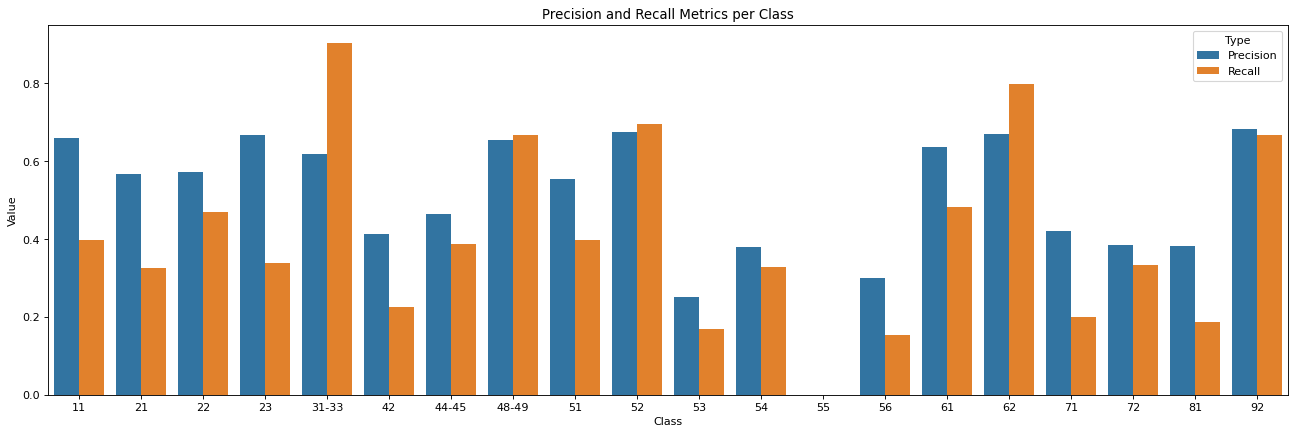

In [30]:
import seaborn as sns

from matplotlib.pyplot import figure

figure(figsize=(20, 6), dpi=80)

sns.barplot(
    data = for_sns,
    x = 'Class',
    y = 'Value',
    hue = 'Type'
)
plt.title('Precision and Recall Metrics per Class')
plt.show()

In [31]:
full_prec = final_metrics['Precision'].mean()
full_recall = final_metrics['Recall'].mean()

print(f'Precision: {full_prec}')
print(f'Recall: {full_recall}')

Precision: 0.49722446454927915
Recall: 0.4062422634733647


In [32]:
print(f'F1-Score: {2 / ((1 / full_prec) + (1 / full_recall))}')

F1-Score: 0.44715225401807673


### Testing Metrics

In [33]:
y_pred_test = rfc_best.predict_proba(X_test_embeds)

# get accuracy scores for OOD validation data
print("=" * 12 + "( Top-K Metrics )" + "=" * 12)
print('Top-1 Accuracy: ' + str(top_k(y_test, y_pred_test, k=1)) + "%")
print('-' * 32)
print('Top-3 Accuracy: ' + str(top_k(y_test, y_pred_test, k=3)) + "%")
print('-' * 32)
print('Top-5 Accuracy: ' + str(top_k(y_test, y_pred_test)) + "%")
print('-' * 32)
print('Top-10 Accuracy: ' + str(top_k(y_test, y_pred_test, k=10)) + "%")

============( Top-K Metrics )============
Top-1 Accuracy: 54.48%
--------------------------------
Top-3 Accuracy: 81.35%
--------------------------------
Top-5 Accuracy: 90.26%
--------------------------------
Top-10 Accuracy: 96.64%


### Out-of-Distribution Testing

In [34]:
# load our embedding data
df_ood = pd.read_csv('embedding_data/embeddings_OOD.csv')

In [35]:
# get a good look at the data
df_ood.head()

,Unnamed: 0,company name,description,model_input,naics2_title,naics2_code,embeddings
0,0,Hotel Sacher,"building in Innere Stadt, Vienna, Austria","Hotel Sacher. building in Innere Stadt, Vienna...",Accommodation and Food Services,72,"[-0.0027582570910453796, -0.001871211919933557..."
1,1,Sberbank,Russian banking and financial services company,Sberbank. Russian banking and financial servic...,Finance and Insurance,52,"[-0.008192808367311954, -0.010321548208594322,..."
2,2,Deutsche Bank,German global banking and financial services c...,Deutsche Bank. German global banking and finan...,Finance and Insurance,52,"[-0.031215853989124298, -0.010979847982525826,..."
3,3,Kasikornbank,Financial institution in Thailand,Kasikornbank. Financial institution in Thailand,Finance and Insurance,52,"[-0.019875941798090935, -0.013805650174617767,..."
4,4,HSBC,British multinational bank,HSBC. British multinational bank,Finance and Insurance,52,"[-0.020594263449311256, -0.01225268840789795, ..."


In [36]:
# perform preprocessing to extract embeddings into its own dataset
df_ood['embeddings'] = df_ood['embeddings'].apply(lambda x: x[1:-1]) # remove the brackets from the estring
ood_embeds = df_ood['embeddings'].apply(lambda x: pd.Series(x.split(", "))) # split by commas to extract numbers
ood_embeds = ood_embeds.map(lambda x: float(x)) # turn these strings into the numbers that they are

# take a look at the embeddings to ensure everything was done correctly
ood_embeds.head()

,0,1,2,3,4,5,6,7,8,9,...,1526,1527,1528,1529,1530,1531,1532,1533,1534,1535
0,-0.002758,-0.001871,0.001849,-0.002849,-0.012716,0.014257,-0.021457,-0.025239,0.021121,-0.013260,...,0.018375,-0.020072,0.034653,-0.014970,-0.045608,0.020862,-0.004649,-0.008883,-0.013312,-0.031234
1,-0.008193,-0.010322,-0.003812,-0.001343,-0.037319,0.006080,-0.018495,-0.023246,0.006639,-0.042676,...,0.030522,-0.028350,0.030472,-0.016676,-0.028526,-0.000325,0.009178,-0.016853,0.007340,-0.004775
2,-0.031216,-0.010980,0.003810,-0.013651,-0.035610,0.026367,-0.029675,0.004811,0.006102,-0.044197,...,-0.000814,-0.037631,0.032100,-0.013689,-0.021354,-0.000335,-0.021025,-0.017856,-0.014926,0.004669
3,-0.019876,-0.013806,0.014186,-0.014225,-0.014199,0.010803,-0.026261,-0.013439,-0.004713,-0.026235,...,0.023009,-0.041718,0.041220,-0.019037,-0.025278,0.011485,0.012154,-0.022957,0.008896,-0.012495
4,-0.020594,-0.012253,-0.003424,-0.018671,-0.037111,0.029724,-0.012663,-0.004071,-0.007854,-0.028442,...,0.010284,-0.023531,0.026852,-0.003975,-0.026493,0.025147,0.001750,-0.006867,0.002095,-0.015067


In [37]:
ood_simplified = ood_embeds[np.arange(0, 65)] # previous PCA concluded 65 embeddings, so let's only take those 65
ood_simplified.head() # look at the data to double check

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,-0.002758,-0.001871,0.001849,-0.002849,-0.012716,0.014257,-0.021457,-0.025239,0.021121,-0.013260,...,-0.006585,-0.009000,0.007219,-0.006883,-0.031701,0.003069,-0.014283,-0.035663,0.018855,-0.035767
1,-0.008193,-0.010322,-0.003812,-0.001343,-0.037319,0.006080,-0.018495,-0.023246,0.006639,-0.042676,...,0.006753,-0.002813,0.011035,0.016196,-0.002369,0.017131,0.002246,-0.023094,-0.010442,-0.026505
2,-0.031216,-0.010980,0.003810,-0.013651,-0.035610,0.026367,-0.029675,0.004811,0.006102,-0.044197,...,0.006440,0.000284,0.002829,0.001861,-0.004597,-0.006926,0.008372,-0.033489,-0.013752,-0.028640
3,-0.019876,-0.013806,0.014186,-0.014225,-0.014199,0.010803,-0.026261,-0.013439,-0.004713,-0.026235,...,0.002956,0.020951,0.001109,-0.002475,-0.019850,0.013937,0.004192,-0.032043,-0.008647,-0.010784
4,-0.020594,-0.012253,-0.003424,-0.018671,-0.037111,0.029724,-0.012663,-0.004071,-0.007854,-0.028442,...,0.001347,0.006505,0.022210,0.005738,-0.004802,0.007373,-0.000088,-0.034572,0.005145,-0.033648


In [38]:
ood_predict = rfc_best.predict_proba(ood_simplified) # predict using our best model
ood_real = df_ood['naics2_code'] # grab the real classification results
ood_real = ood_real.rename('NAICS_2 Code') # rename for our function (because otherwise it'll crash)

In [39]:
# get accuracy scores for OOD validation data
print("=" * 12 + "( Top-K Metrics )" + "=" * 12)
print('Top-1 Accuracy: ' + str(top_k(ood_real, ood_predict, k=1)) + "%")
print('-' * 32)
print('Top-3 Accuracy: ' + str(top_k(ood_real, ood_predict, k=3)) + "%")
print('-' * 32)
print('Top-5 Accuracy: ' + str(top_k(ood_real, ood_predict)) + "%")
print('-' * 32)
print('Top-10 Accuracy: ' + str(top_k(ood_real, ood_predict, k=10)) + "%")

============( Top-K Metrics )============
Top-1 Accuracy: 5.95%
--------------------------------
Top-3 Accuracy: 16.98%
--------------------------------
Top-5 Accuracy: 40.81%
--------------------------------
Top-10 Accuracy: 69.4%
